In [1]:
import random as rand
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T
from torch.nn.init import kaiming_uniform_
import tqdm
from matplotlib import pyplot as plt

In [2]:
class OU_noise():
    def __init__(self,mu,sigma=0.3,theta=0.15,dt=1e-5,x0=None):
        self.theta = theta
        self.mu    = mu
        self.sigma = sigma
        self.dt    = dt
        self.x0    = x0
        self.reset()
        
    def __call__(self):
        x = self.x_prev + self.theta * (self.mu - self.x_prev)* \
                self.dt +self.sigma * np.sqrt(self.dt)*np.random.normal(size = self.mu.shape)
        self.x_prev = x
        return x
    
    def reset(self):
        self.x_prev = self.x0 if self.x0 is not None else np.zeros_like(self.mu)

In [3]:
class ReplayMemory():
    def __init__(self,capacity):   
        self.capacity = capacity
        self.memory = []
        self.push_count = 0
        
    def push(self, experience):
        if len(self.memory) < self.capacity:
            self.memory.append(experience)
        else:
            self.memory[self.push_count%self.capacity] = experience
        self.push_count+=1
    
    def sample(self, batch_size):
        return rand.sample(self.memory,batch_size)
    
    def can_provide_sample(self, batch_size):
        return len(self.memory)>=batch_size
    
    def update_td_error(self, sampled_experiences):
        for sampled_idx,sampled_exp in enumerate(sampled_experiences):
            for mem_idx, mem_exp in enumerate(self.memory):
                if mem_exp.timestep == sampled_exp.timestep:
                    self.memory[mem_idx] = sampled_exp #update memory
                    break
        
    def get_memory_values(self):
        return self.memory    

In [4]:
def extract_tensors(experiences):
    #print(".....................................................")
    #print(experiences)
    batch = Xp(*zip(*experiences))
    state = np.stack(batch.state) #stack
    action = np.stack(batch.action)
    next_state = np.stack(batch.next_state)
    reward = np.stack(batch.reward)
    done = np.stack(batch.done)
    abs_td_error = np.stack(batch.abs_td_error)
    timestep = np.stack(batch.timestep)
    return state,action,next_state,reward,done,abs_td_error,timestep

In [5]:
def rebuild_experiences(state, action, next_state, reward, done, abs_error, timestep):
    exp_list = []
    for idx_ in range(len(state)):
        exp_list.append(\
                        Xp(state[idx_], action[idx_], next_state[idx_], reward[idx_],\
                           done[idx_], abs_error[idx_], timestep[idx_]))
    return exp_list

In [6]:
from collections import namedtuple
Xp = namedtuple('Experience',
                        ('state', 'action', 'next_state', 'reward', 'done', 'abs_td_error','timestep'))
Xp_points = Xp(5,6,7,8,9,10,11)
Xp_points

Experience(state=5, action=6, next_state=7, reward=8, done=9, abs_td_error=10, timestep=11)

In [7]:
class linearApproximator_FCDCAP(nn.Module):
    def __init__(self,state_shape,outputs,hidden_dims=(32,32)):
        super(linearApproximator_FCDCAP, self).__init__()
        self.input_size = state_shape
        self.out = outputs
        self.device = torch.device("cuda" if torch.cuda.is_available()\
                                   else "cpu")
        
        self.fc1  = nn.Linear(self.input_size,hidden_dims[0])
        self.input_bn = nn.BatchNorm1d(hidden_dims[0])
        self.hidden_layers = nn.ModuleList()
        self.hidden_bn = nn.ModuleList()
        for i in range(len(hidden_dims)-1):
            hidden_layer = nn.Linear(\
                                hidden_dims[i], hidden_dims[i+1])
            hidden_bn = nn.BatchNorm1d(hidden_dims[i+1])
            self.hidden_layers.append(hidden_layer)
            self.hidden_bn.append(hidden_bn)
        
        self.output_layer  = nn.Linear(hidden_dims[-1],self.out)
        self.tan_h = torch.nn.Tanh()
        self.to(self.device)
        
    def forward(self, state_shape):
        if not isinstance(state_shape, torch.Tensor):
            state_shape = torch.tensor(state_shape, dtype=torch.float32)
        state_shape = state_shape.to(self.device)
            
        x = self.fc1(state_shape)
        x = self.input_bn(x)
        x = F.relu(x)
        
        for i in range(len(self.hidden_layers)):
            x = self.hidden_layers[i](x)
            x = self.hidden_bn[i](x)
            x = F.relu(x)
            
        
        unscaled_output = self.output_layer(x)#logits, preferences of actions
        scaled_output = (self.tan_h(unscaled_output) + 1) / 2
        return scaled_output

In [9]:
class linearApproximator_FCQV(nn.Module):#Q value of state action pair
    def __init__(self,state_shape,action_outputs_size,hidden_dims=(32,32)):
        super(linearApproximator_FCQV, self).__init__()
        self.input_size = state_shape
        self.action_outputs_size = action_outputs_size
        self.device = torch.device("cuda" if torch.cuda.is_available()\
                                   else "cpu")
        
        self.fc1  = nn.Linear(self.input_size,hidden_dims[0])
        self.input_bn = nn.BatchNorm1d(hidden_dims[0])
        self.hidden_layers = nn.ModuleList()
        self.hidden_bn = nn.ModuleList()
        
        for i in range(len(hidden_dims)-1):
            hidden_input_layer = hidden_dims[i]
            hidden_input_layer += self.action_outputs_size # we now add actions to each layer neuron
            hidden_layer = nn.Linear(\
                                hidden_input_layer, hidden_dims[i+1])
            hidden_bn = nn.BatchNorm1d(hidden_dims[i+1])
            self.hidden_layers.append(hidden_layer)
            self.hidden_bn.append(hidden_bn)
        
        self.output_layer  = nn.Linear(hidden_dims[-1], 1) # output layer
        self.tan_h = torch.nn.Tanh()
        self.to(self.device)
        
    def forward(self, state_shape, action_shape):
        if not isinstance(state_shape, torch.Tensor):
            state_shape = torch.tensor(state_shape, dtype=torch.float32).to(self.device)
        if not isinstance(action_shape, torch.Tensor):
            action_shape = torch.tensor(action_shape, dtype=torch.float32).to(self.device)
                    
        x = self.fc1(state_shape)
        x = self.input_bn(x)
        x = F.relu(x)
    
        for idx, hidden_layer in enumerate(self.hidden_layers):
            x = torch.cat((x, action_shape), dim=1)
            x = hidden_layer(x)
            x = self.hidden_bn[idx](x) 
            x = F.relu(x)
            
        
        q_value = self.output_layer(x)#logits, preferences of actions
        return q_value

In [10]:
def update_networks(online_policy_network, online_q_network_a, online_q_network_b,\
                    offline_policy_network, offline_q_network_a, offline_q_network_b, tau):
    #polyak averaging: pg:319
    for target_weights, online_weights in zip(offline_policy_network.parameters(), online_policy_network.parameters()):
        target_weight_update = (1.0 - tau)*target_weights.data
        online_weight_update = tau*online_weights.data
        sum_up = target_weight_update + online_weight_update
        target_weights.data.copy_(sum_up)
        
    for target_weights, online_weights in zip(offline_q_network_a.parameters(), online_q_network_a.parameters()):
        target_weight_update = (1.0 - tau)*target_weights.data
        online_weight_update = tau*online_weights.data
        sum_up = target_weight_update + online_weight_update
        target_weights.data.copy_(sum_up)
        
    for target_weights, online_weights in zip(offline_q_network_b.parameters(), online_q_network_b.parameters()):
        target_weight_update = (1.0 - tau)*target_weights.data
        online_weight_update = tau*online_weights.data
        sum_up = target_weight_update + online_weight_update
        target_weights.data.copy_(sum_up)

    return offline_policy_network, offline_q_network_a, offline_q_network_b

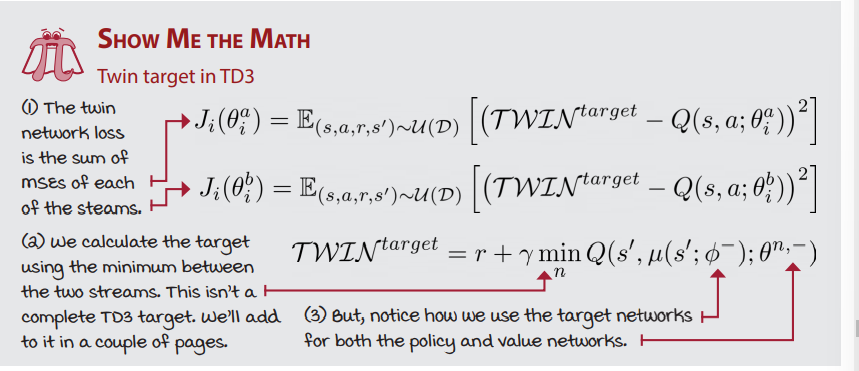

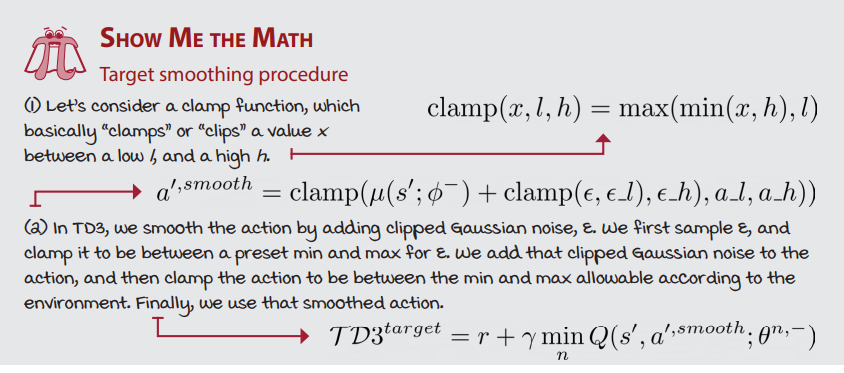

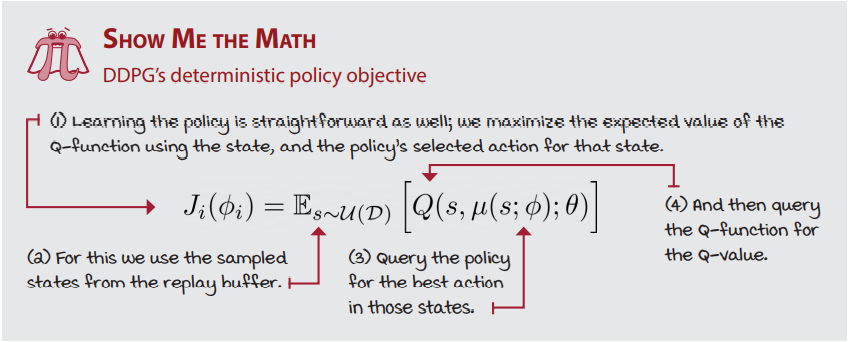

In [22]:
def update_online_model(experience_samples,\
                        online_policy_network, online_q_network_a, online_q_network_b,\
                        online_policy_optimizer, online_q_optimizer_a, online_q_optimizer_b,\
                        offline_policy_network, offline_q_network_a, offline_q_network_b,\
                        gamma, weighted_importance, indices, current_t_step, update_online_policy):
    
    states, actions, next_states, rewards, done, td_errors, timesteps = extract_tensors(experience_samples)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    states = np.squeeze(states)
    next_states = np.squeeze(next_states)
    
    
    #rearrange first
    arrange_weighted_values = [indices.index(i) for i in timesteps]
    
    states = torch.tensor(states).float().to(device)
    actions = torch.tensor(actions)
    # actions = actions.type(torch.LongTensor).to(device) # CAUSED BIG ERRORS CAUSE OF LONGTENSOR
    actions = torch.tensor(actions).float().to(device)
    # print("actions float: ", actions)
    next_states=torch.tensor(next_states).float().to(device)
    rewards = torch.tensor(rewards).float().to(device)
    rewards = rewards.unsqueeze(1)
    done = torch.tensor(done).float().to(device)
    done = done.unsqueeze(1)
    weighted_importance = torch.tensor(weighted_importance).float().to(device)
    weighted_importance = weighted_importance[arrange_weighted_values,:]
    
    max_q_sa_online_a = online_q_network_a(states, actions)
    max_q_sa_online_b = online_q_network_b(states, actions)
    #max_q_sa_online_a*=weighted_importance.detach()
    #max_q_sa_online_b*=weighted_importance.detach()print(f"TWIN_target: {TWIN_target.mean().item():.4f}")

    #if current_t_step % 100 == 0:
        #print(f"Q1: {max_q_sa_online_a.mean().item():.4f}")
        #print(f"Q2: {max_q_sa_online_b.mean().item():.4f}")
        # print(f"TWIN_target: {TWIN_target.mean().item():.4f}")
        #print(f"rewards: {rewards.mean().item():.4f}")
    
    #calculate twin target
    #remember for this method, we add noise to the actions of offline networks
    predicted_offline_action_policy = offline_policy_network(next_states)#we add noise to this 
    #predicted_offline_action_policy_noise = #we get noise(not done)
    
    #print("before noise: ", predicted_offline_action_policy.shape)
    # action_noise = torch.clamp(torch.tensor(np.random.normal(loc = 0, scale = 0.05)),-0.01,0.01)#IMPORTANT - CHANGE NOISE TO BE 10 PERCENT OF TORQUE
    action_noise = torch.clamp(
    torch.tensor(np.random.normal(loc=0, scale=0.05, size=(states.shape[0], 4))).float(),
    -0.05, 0.05).to(device)
    #print("action noise: ", action_noise)
    predicted_offline_action_policy += action_noise
    predicted_offline_action_policy = torch.clamp(\
                                      predicted_offline_action_policy,0.0,1.0)#set bounds of output to match min-max torque IMPORTANT
    
    #print("after noise: ", predicted_offline_action_policy.shape)
    
    
    max_q_sa_offline_a = offline_q_network_a(next_states, predicted_offline_action_policy)
    max_q_sa_offline_b = offline_q_network_b(next_states, predicted_offline_action_policy)
    max_q_sa_offline = torch.min(max_q_sa_offline_a, max_q_sa_offline_b)
    TWIN_target = max_q_sa_offline
    
    
    
    
    TWIN_target = TWIN_target.detach()
    
    if current_t_step % 100 == 0:
        print(f"Q1: {max_q_sa_online_a.mean().item():.4f}")
        print(f"Q2: {max_q_sa_online_b.mean().item():.4f}")
        #print(f"done mean: {done.mean().item():.4f}")
        print(f"TWIN_target: {TWIN_target.mean().item():.4f}")
        print(f"TWIN_target before reward: {(gamma * max_q_sa_offline).mean().item():.4f}")
        print(f"rewards: {rewards.mean().item():.4f}")
    
    TWIN_target *=(1 - done) 
    TWIN_target = rewards + gamma*TWIN_target
    #TWIN_target*=weighted_importance.detach()
    #if current_t_step % 100 == 0:
        #print(f"TWIN_target after reward: {TWIN_target.mean().item():.4f}")
    abs_a = abs(TWIN_target.detach().cpu().numpy() - max_q_sa_online_a.detach().cpu().numpy())
    abs_b = abs(TWIN_target.detach().cpu().numpy() - max_q_sa_online_b.detach().cpu().numpy())
    ovr_abs_update = (abs_a + abs_b)/2 
    loss_func = torch.nn.SmoothL1Loss(reduction='none')
    q_online_value_loss_a = (weighted_importance.detach() *loss_func(max_q_sa_online_a,\
                                             TWIN_target)).mean()
    q_online_value_loss_b = (weighted_importance.detach() *loss_func(max_q_sa_online_b,\
                                             TWIN_target)).mean()
    online_q_optimizer_a.zero_grad()
    q_online_value_loss_a.backward()
    online_q_optimizer_a.step()
    online_q_optimizer_b.zero_grad()
    q_online_value_loss_b.backward()
    online_q_optimizer_b.step()
    
    #another difference is over DDPG, we delay online policy updates - allows value func to settle
    #optimize model is same as ddpg - but we rake only one of the value function approximators
    if current_t_step%update_online_policy == 0:
        max_q_actions_online = online_policy_network(states)
        qsa_values_a = online_q_network_a(states, max_q_actions_online)
        policy_loss = -qsa_values_a.mean()
        online_policy_optimizer.zero_grad()
        policy_loss.backward()
        online_policy_optimizer.step()
        
    states, actions, next_states, rewards, done, td_errors, timesteps = extract_tensors(experience_samples)
    experiences_rebuilded = rebuild_experiences(states, actions, next_states, rewards, done, ovr_abs_update, timesteps)
    return experiences_rebuilded,online_policy_network 

In [23]:
def query_error(offline_policy_network, offline_q_network_a, offline_q_network_b,\
                online_q_network_a, online_q_network_b, state, next_state, action, reward, gamma):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    state = torch.tensor(state).float().to(device)
    state = state.unsqueeze(0)
    next_state = torch.tensor(next_state).float().to(device)
    next_state = next_state.unsqueeze(0)
    
    
    
    q_offline_max_actions = offline_policy_network(next_state)
    q_target_next_states_action_a = offline_q_network_a(next_state,\
                                                    q_offline_max_actions.detach())
    q_target_next_states_action_b = offline_q_network_b(next_state,\
                                                    q_offline_max_actions.detach())
    TWIN_target = torch.min(q_target_next_states_action_a, q_target_next_states_action_b)
    TWIN_target = reward + (gamma*TWIN_target.detach())
    action = np.expand_dims(action, axis=0)

    online_q_network_a.eval()
    online_q_network_b.eval()
    q_online_state_action_val_a = online_q_network_a(state, action)
    q_online_state_action_val_b = online_q_network_b(state, action)
    online_q_network_a.train()
    online_q_network_b.train()
    
    abs_a = abs(TWIN_target - q_online_state_action_val_a)
    abs_b = abs(TWIN_target - q_online_state_action_val_b)
    abs_stack = (abs_a + abs_b)/2
    #print("abs querry error stacked: ", abs_stack.shape)
    ovr_abs_update = abs_stack
    #print("abs querry error mean: ", ovr_abs_update.shape)
    return ovr_abs_update.detach().cpu().numpy()

In [24]:
def prioritize_samples(experience_samples, alpha, beta):
    state,action,next_state,reward,done,abs_td_error,timesteps \
                            = extract_tensors(experience_samples)
    abs_td_error, indices_ = (list(t) for t in zip(*sorted(\
                            zip(abs_td_error.tolist(), timesteps))))
    abs_td_error.reverse()
    indices_.reverse()#reverse to march sort func
    abs_td_error = np.array(abs_td_error)
    abs_td_error  = torch.tensor(abs_td_error)
    ranks = np.arange(1, len(abs_td_error)+1)
    priorities = 1.0/ranks
    priorities = priorities**alpha
    priorities = np.expand_dims(priorities, axis=1)
    probabilities = priorities/np.sum(priorities, axis=0)
    assert np.isclose(probabilities.sum(), 1.0)
    number_of_samples  = len(probabilities)
    weight_importance_ = number_of_samples*probabilities
    weight_importance_ = weight_importance_**-beta
    weight_importance_max = np.max(weight_importance_)
    weight_importance_scaled = weight_importance_/weight_importance_max
    return weight_importance_scaled, indices_ 

In [25]:
def freeze_model(model):
    for param in model.parameters():
        param.requires_grad = False
    return model

In [26]:
def select_action(state, online_policy_network, noise):
    online_policy_network.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    state = torch.tensor(state).float().to(device)
    state = state.unsqueeze(0)
    with torch.no_grad():
        max_action_value = online_policy_network(state).cpu().detach()
        # print("net stat before: ", max_action_value)
        max_action_value = max_action_value.data.numpy().squeeze()
        max_action_value = max_action_value + noise()
        #print("net stat: ", max_action_value)
    online_policy_network.train()
    return max_action_value

In [27]:
import time

In [28]:
def TD3_PER(env,
         gamma=0.99,
         alpha_pr=0.6,
         beta_pr=0.4,
         memory_size = 100000,
         tau = 0.08,
         offline_update = 150,
         min_sample_size=1000,
         batch_size = 64,
         n_ep=1000,
         max_steps = 100000000,
         update_online_policy =2
         ):
    
    
    observation_space = len(env.reset()[0])
    
    n_actions = 4
    online_policy_network = linearApproximator_FCDCAP(observation_space,n_actions,\
                                     hidden_dims=(250, 250))
    online_q_network_a = linearApproximator_FCQV(observation_space,\
                                     n_actions,hidden_dims=(250, 250))
    online_q_network_b = linearApproximator_FCQV(observation_space,\
                                     n_actions,hidden_dims=(250, 250))
    
    offline_policy_network = linearApproximator_FCDCAP(observation_space,n_actions,\
                                     hidden_dims=(250, 250))
    offline_q_network_a = linearApproximator_FCQV(observation_space,\
                                     n_actions,hidden_dims=(250, 250))
    offline_q_network_b = linearApproximator_FCQV(observation_space,\
                                     n_actions,hidden_dims=(250, 250))

    offline_policy_network.load_state_dict(online_policy_network.state_dict())
    offline_q_network_a.load_state_dict(online_q_network_a.state_dict())
    offline_q_network_b.load_state_dict(online_q_network_b.state_dict())


    
    noise_ = OU_noise(np.zeros((n_actions)), sigma=0.1, dt=0.01)
    offline_policy_network.eval()
    offline_policy_network = freeze_model(offline_policy_network)
    offline_q_network_a.eval()
    offline_q_network_a = freeze_model(offline_q_network_a)
    offline_q_network_b.eval()
    offline_q_network_b = freeze_model(offline_q_network_b)

    online_policy_optimizer    = torch.optim.Adam(online_policy_network.parameters(),lr=0.00001)
    online_q_optimizer_a = torch.optim.Adam(online_q_network_a.parameters(),lr=0.00001)
    online_q_optimizer_b = torch.optim.Adam(online_q_network_b.parameters(),lr=0.00001)
    
    memory = ReplayMemory(memory_size)
    
    t_step = 0 #important
    reward_per_ep = []
    
    
    for e in tqdm(range(n_ep)):
        state = env.reset()[0]
        reward_accumulated = 0
        
        while True:
            env.render()
            action = select_action(state, online_policy_network, noise_)
            
            next_state, reward, done, truncated, info = env.step(action)
            # print("reward: ", reward, "ns: ", next_state)
            td_error = query_error(offline_policy_network, offline_q_network_a, offline_q_network_b,\
                                    online_q_network_a, online_q_network_b,\
                                    state, next_state, action, reward, gamma)
            #print("td error: ", td_error.shape)
            td_error = np.squeeze(td_error, axis = 0)
            #print("td error: ", td_error.shape)
            reward_accumulated+=reward
            is_truncated = truncated
            is_failure = done and not is_truncated

            # print("state: ", state, "nexr_state: ", next_state, " action: ", action, "reward: ", reward, " fail: ", is_failure)
            memory.push(Xp(state, action, next_state, reward, is_failure, td_error, t_step))
            state = next_state
            t_step+=1
            if memory.can_provide_sample(min_sample_size):
                experience_samples = memory.sample(batch_size)
                weighted_importance, indices = prioritize_samples(experience_samples, alpha_pr, beta_pr)
                rebuilded_exp, online_policy_network = update_online_model(experience_samples,\
                        online_policy_network, online_q_network_a, online_q_network_b,\
                        online_policy_optimizer, online_q_optimizer_a, online_q_optimizer_b,\
                        offline_policy_network, offline_q_network_a, offline_q_network_b,\
                        gamma, weighted_importance, indices, t_step, update_online_policy)
                memory.update_td_error(rebuilded_exp)
                
            if t_step%offline_update == 0:
                offline_policy_network, offline_q_network_a, offline_q_network_b = update_networks(online_policy_network, online_q_network_a,\
                                                                        online_q_network_b,offline_policy_network,\
                                                                        offline_q_network_a, offline_q_network_b, tau)
            if done == True:
                reward_per_ep.append(reward_accumulated)
                #print(reward_accumulated)
                break
        if e % 10 == 0 and e > 0:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            test_state = torch.tensor(env.reset()[0]).float().unsqueeze(0).to(device)
            good_action = torch.tensor([[0.6, 0.6, 0.6, 0.6]]).float().to(device)
            bad_action  = torch.tensor([[0.3, 0.3, 0.3, 0.3]]).float().to(device)
            
            online_q_network_a.eval()
            online_q_network_b.eval()
            q_good_a = online_q_network_a(test_state, good_action).item()
            q_bad_a  = online_q_network_a(test_state, bad_action).item()
            q_good_b = online_q_network_b(test_state, good_action).item()
            q_bad_b  = online_q_network_b(test_state, bad_action).item()
            online_q_network_a.train()
            online_q_network_b.train()
            
            print(f"\n=== CHECKPOINT ep {e} ===")
            print(f"oqa: Q(good)={q_good_a:.4f}  Q(bad)={q_bad_a:.4f}  gap={q_good_a - q_bad_a:.4f}")
            print(f"oqb: Q(good)={q_good_b:.4f}  Q(bad)={q_bad_b:.4f}  gap={q_good_b - q_bad_b:.4f}")
            print(f"avg reward last 50 eps: {np.mean(reward_per_ep[-50:]):.4f}")
            print(f"========================\n")
    env.close()           
    return reward_per_ep,online_policy_network,online_q_network_a,online_q_network_b

In [29]:
#env = gym.make("Pendulum-v0")#baseline env
#env = gym.make('BipedalWalker-v3')
from env.drone_env import DroneEnv
env = DroneEnv(render_mode="human", target_pos=[0.0, 0.0, 1.0])

In [30]:
def plot_grad_flow(named_parameters):
    ave_grads = []
    layers = []
    for n, p in named_parameters:
        if(p.requires_grad) and ("bias" not in n):
            layers.append(n)
            ave_grads.append(p.grad.abs().mean().detach().cpu().numpy())
    plt.plot(ave_grads, alpha=0.3, color="b")
    plt.hlines(0, 0, len(ave_grads)+1, linewidth=1, color="k" )
    plt.xticks(range(0,len(ave_grads), 1), layers, rotation="vertical")
    plt.xlim(xmin=0, xmax=len(ave_grads))
    plt.xlabel("Layers")
    plt.ylabel("average gradient")
    plt.title("Gradient flow")
    plt.grid(True)

In [33]:
env.close()

In [32]:
from tqdm import tqdm
rewards, pn, oqa, oqb = TD3_PER(env)  

  1%|▉                                                                               | 11/1000 [00:03<05:42,  2.89it/s]


=== CHECKPOINT ep 10 ===
oqa: Q(good)=-0.0510  Q(bad)=-0.0493  gap=-0.0017
oqb: Q(good)=0.1275  Q(bad)=0.1273  gap=0.0002
avg reward last 50 eps: 5.9152



  2%|█▋                                                                              | 21/1000 [00:06<05:32,  2.95it/s]


=== CHECKPOINT ep 20 ===
oqa: Q(good)=-0.0484  Q(bad)=-0.0512  gap=0.0028
oqb: Q(good)=0.1012  Q(bad)=0.1059  gap=-0.0047
avg reward last 50 eps: 4.1394



  3%|██▍                                                                             | 31/1000 [00:09<05:47,  2.79it/s]

...

Q1: 0.1874
Q2: 0.1924
TWIN_target: -0.0221
TWIN_target before reward: -0.0218
rewards: 0.1500


 49%|██████████████████████████████████████▊                                        | 491/1000 [04:11<05:10,  1.64it/s]


=== CHECKPOINT ep 490 ===
oqa: Q(good)=1.4012  Q(bad)=1.3861  gap=0.0150
oqb: Q(good)=1.3400  Q(bad)=1.3353  gap=0.0047
avg reward last 50 eps: 1.7375



 49%|███████████████████████████████████████                                        | 494/1000 [04:13<04:19,  1.95it/s]


KeyboardInterrupt: 

In [57]:
test_state = torch.tensor(env.reset()[0]).float().unsqueeze(0).to("cpu")
good_action = torch.tensor([[0.6, 0.6, 0.6, 0.6]]).float().to("cpu")
bad_action  = torch.tensor([[0.3, 0.3, 0.3, 0.3]]).float().to("cpu")
oqb.eval()
print(f"Q(good): {oqb(test_state, good_action).item():.4f}")
print(f"Q(bad):  {oqb(test_state, bad_action).item():.4f}")
oqb.train()

Q(good): 2.6485
Q(bad):  2.6351


linearApproximator_FCQV(
  (fc1): Linear(in_features=16, out_features=120, bias=True)
  (input_bn): BatchNorm1d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (hidden_layers): ModuleList(
    (0-1): 2 x Linear(in_features=124, out_features=120, bias=True)
  )
  (hidden_bn): ModuleList(
    (0-1): 2 x BatchNorm1d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (output_layer): Linear(in_features=120, out_features=1, bias=True)
  (tan_h): Tanh()
)

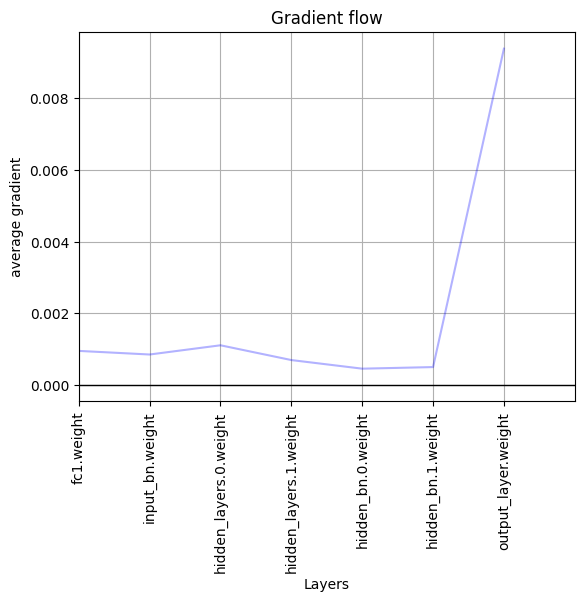

In [27]:
plot_grad_flow(oqb.named_parameters())

In [43]:
env.close()

In [22]:
from scipy.ndimage.filters import uniform_filter1d
arr = uniform_filter1d(rewards, size=50)

C:\Users\ScottKikumu\AppData\Local\Temp\ipykernel_16988\3803450863.py:1: DeprecationWarning: Please import `uniform_filter1d` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import uniform_filter1d


In [23]:
from matplotlib import pyplot as plt
x = []
y = []
for i,e in enumerate(arr):
    y.append(i)
    x.append(e)

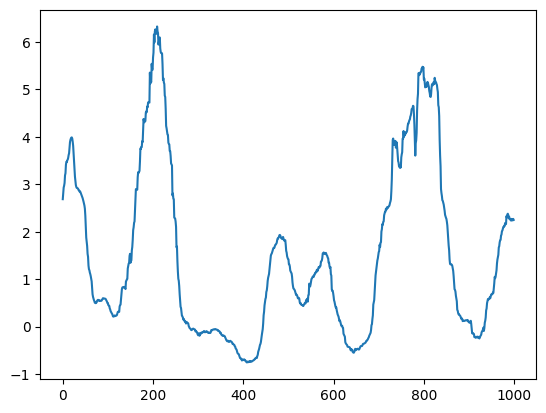

In [24]:
plt.plot(y, x)#70% BIAS correction

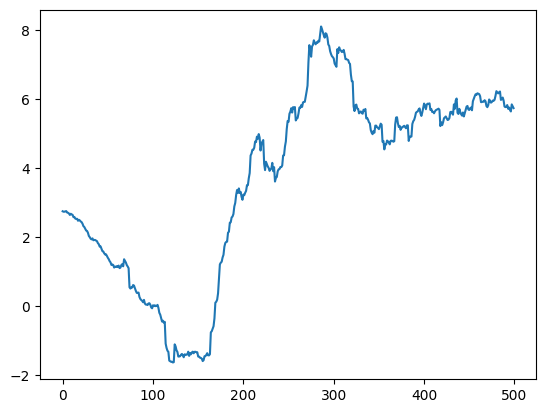

In [42]:
plt.plot(y, x)#no bias correction

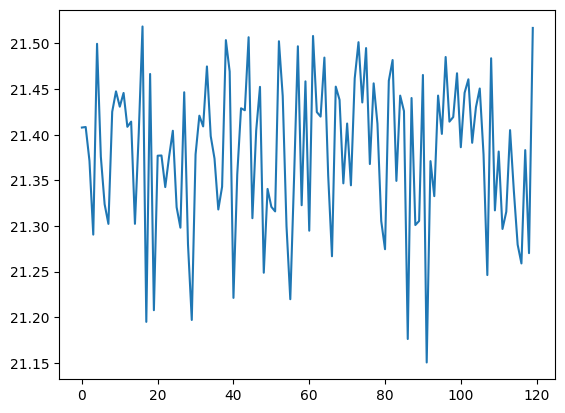

In [81]:
plt.plot(y, x)#50% bias correction

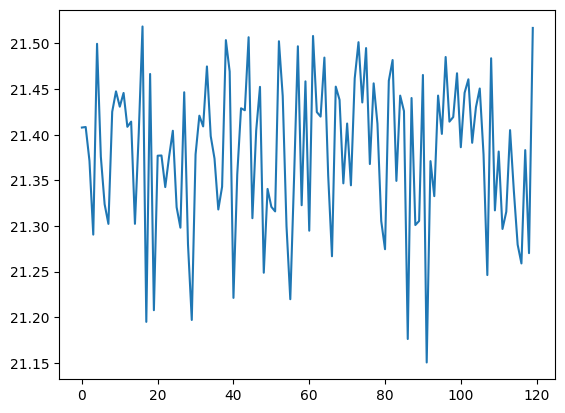

In [82]:
plt.plot(y, x)#full bias correction

In [30]:
memory

NameError: name 'memory' is not defined